# **Notebook 3.1 -- Shallow neural networks I (Julia version)**

The purpose of this notebook is to gain some familiarity with shallow neural networks with 1D inputs. It works through an example similar to figure 3.3 and experiments with different activation functions.

Work through the cells below, running each cell in turn. In various places you will see the words "TODO". Follow the instructions at these places and write code to complete the functions. There are also questions interspersed in the text.

This is a Julia port of the original Python notebook. It uses `Plots.jl` for plotting. If you don't have the packages, run:
```julia
import Pkg; Pkg.add(["Plots", "Printf"])
```

Original notebook by the *Understanding Deep Learning* book authors (udlbookmail@gmail.com).

In [2]:
using Plots 
using Printf

Let's first construct the shallow neural network with one input, three hidden units, and one output described in section 3.1 of the book.


In [13]:
# Define the Rectified Linear Unit (ReLU) function
function ReLU(preactivation)
    activation = max.(0.0, preactivation)
    return activation 
end

ReLU (generic function with 1 method)

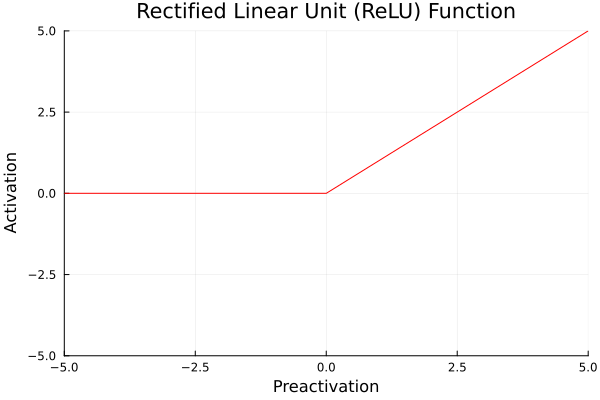

In [14]:
z = collect(-5:0.1:5)
RELU_z = ReLU(z)

# plot the RELU function
plot(z, RELU_z, color=:red, legend=false, 
    xlims=(-5, 5), ylims=(-5, 5),
    xlabel="Preactivation",
    ylabel="Activation",
    title="Rectified Linear Unit (ReLU) Function", titlefont=font(14))

In [9]:
# Define a shallow neural network with one input, one output, and three hidden units
function shallow_1_1_3(x, activation_fn, ϕ₀, ϕ₁, ϕ₂, ϕ₃, θ₁₀, θ₁₁, θ₂₀, θ₂₁, θ₃₀, θ₃₁)
    # from the theta parameters (i.e. implement equations at bottom of figure 3.3a-c).
    # These are the preactivations
    pre_1 = θ₁₀ .+ θ₁₁ .* x
    pre_2 = θ₂₀ .+ θ₂₁ .* x
    pre_3 = θ₃₀ .+ θ₃₁ .* x

    # Pass these through the ReLU function to compute the activations as in
    # figure 3.3 d-f
    act_1 = activation_fn(pre_1)
    act_2 = activation_fn(pre_2)
    act_3 = activation_fn(pre_3)

    # Finally, compute the output of the network as in figure 3.3 g-i
    w_act_1 = ϕ₁ .* act_1
    w_act_2 = ϕ₂ .* act_2
    w_act_3 = ϕ₃ .* act_3

    output = ϕ₀ .+ w_act_1 .+ w_act_2 .+ w_act_3

    return output, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3
end 



shallow_1_1_3 (generic function with 1 method)

In [10]:
function plot_neural(x, output, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3;
    plot_all=false, x_data=nothing, y_data=nothing)

    # Plot intermediate plots if flag set 
    if plot_all
        p = plot(layout=(3,3), size=(900, 900), legend=false)

        plot!(p[1], x, pre_1, color=:red, ylabel="Preactivation")
        plot!(p[2], x, pre_2, color=:blue, ylabel="Preactivation")
        plot!(p[3], x, pre_3, color=:green, ylabel="Preactivation")
        plot!(p[4], x, act_1, color=:red, ylabel="Activation")
        plot!(p[5], x, act_2, color=:blue, ylabel="Activation")
        plot!(p[6], x, act_3, color=:green, ylabel="Activation")
        plot!(p[7], x, w_act_1, color=:red, ylabel="Weighted Activation")
        plot!(p[8], x, w_act_2, color=:blue, ylabel="Weighted Activation")
        plot!(p[9], x, w_act_3, color=:green, ylabel="Weighted Activation")

        for i in 1:9
            plot!(p[i], xlims=(0, 1), ylims=(-1, 1))
        end
        display(p)
    end 

    fig = plot(x, output, xlabel="Input, x", ylabel="Output, y",
            xlims=(0,1), ylims=(-1,1), legend=false)
    if x_data != nothing
        scatter!(fig, x_data, y_data, color=:magneta)
    end 
    display(fig)
end

plot_neural (generic function with 1 method)

In [15]:
# Define some parameters for neural network 
θ₁₀ = 0.3; θ₁₁ = -1.0
θ₂₀ = -1.0; θ₂₁ = 2.0
θ₃₁ = -0.5; θ₃₁ = 0.65 
ϕ₀ = -0.3; ϕ₁ = 2.0; ϕ₂ = -1.0; ϕ₃ = 7.0 

# Define a range input values 
x = collect(0:0.01:1)

# run the neural network for each of these input values 
output, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = 
    shallow_1_1_3(x, ReLU, ϕ₀, ϕ₁, ϕ₂, ϕ₃, θ₁₀, θ₁₁, θ₂₀, θ₂₁, θ₃₀, θ₃₁)

# Then plot it 
plot_neural(x, output, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=true)

LoadError: UndefVarError: `θ₃₀` not defined in `Main`
Suggestion: check for spelling errors or missing imports.